In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Dataset path

import os

DATASET_NAME = 'PlantDoc'
base_path  = f'/content/drive/MyDrive/ML Project Dataset /Plant Village/Tomato'

train_path = os.path.join(base_path, 'Train')
val_path   = os.path.join(base_path, 'Val')
test_path  = os.path.join(base_path, 'Test')

print("Base  :", base_path)
print("Train :", train_path)
print("Val   :", val_path)
print("Test  :", test_path)

print("Train exists :", os.path.exists(train_path))
print("Val   exists :", os.path.exists(val_path))
print("Test  exists :", os.path.exists(test_path))

Base  : /content/drive/MyDrive/ML Project Dataset /Plant Village/Tomato
Train : /content/drive/MyDrive/ML Project Dataset /Plant Village/Tomato/Train
Val   : /content/drive/MyDrive/ML Project Dataset /Plant Village/Tomato/Val
Test  : /content/drive/MyDrive/ML Project Dataset /Plant Village/Tomato/Test
Train exists : True
Val   exists : True
Test  exists : True


In [ ]:
# all disease classes
classes = sorted([
    c for c in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, c))
])

print(f"Total Number of Classes: {len(classes)}")
print("\nDisease Classes")
for i, class_name in enumerate(classes, 1):
    print(f"  {i:2d}. {class_name}")

Total Number of Classes: 6

Disease Classes
   1. Bacterial Spot
   2. Early Blight
   3. Healthy
   4. Late Blight
   5. Septoria Leaf Spot
   6. Yellow Leaf Curl Virus


In [ ]:
#Count images per class across all splits
import pandas as pd

def count_images_per_class(dataset_path, classes):

    counts = {}
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        if os.path.exists(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])
        else:
            counts[class_name] = 0
    return counts

train_counts = count_images_per_class(train_path, classes)
val_counts   = count_images_per_class(val_path,   classes)
test_counts  = count_images_per_class(test_path,  classes)

df = pd.DataFrame({
    'Class': classes,
    'Train': [train_counts[c] for c in classes],
    'Val':   [val_counts[c]   for c in classes],
    'Test':  [test_counts[c]  for c in classes],
})
df['Total'] = df['Train'] + df['Val'] + df['Test']

print("Image Distribution Across Classes \n")
print(df.to_string(index=False))

print(f"\nSummary")
print(f"Total Training Images   : {df['Train'].sum()}")
print(f"Total Validation Images : {df['Val'].sum()}")
print(f"Total Test Images       : {df['Test'].sum()}")
print(f"Grand Total             : {df['Total'].sum()}")

Image Distribution Across Classes 

                 Class  Train  Val  Test  Total
        Bacterial Spot   1702  382    43   2127
          Early Blight   1920  432    48   2400
               Healthy   1926  432    49   2407
           Late Blight   1851  416    47   2314
    Septoria Leaf Spot   1745  399    44   2188
Yellow Leaf Curl Virus   1961  441    49   2451

Summary
Total Training Images   : 11105
Total Validation Images : 2502
Total Test Images       : 280
Grand Total             : 13887


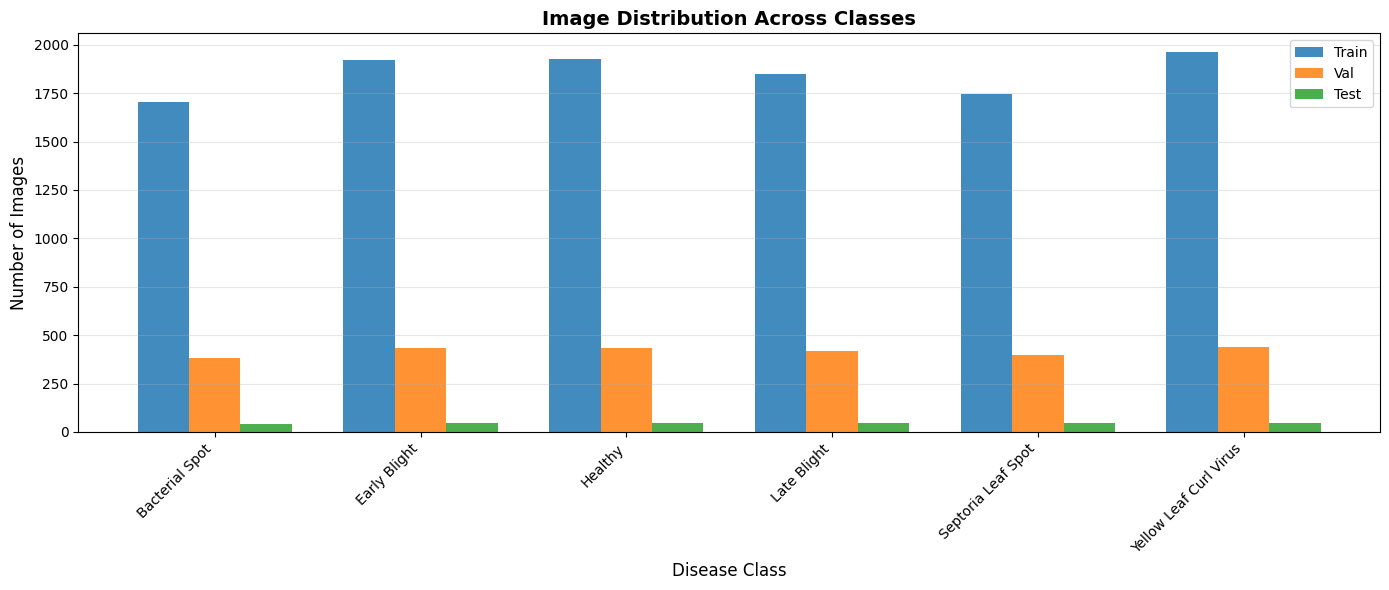

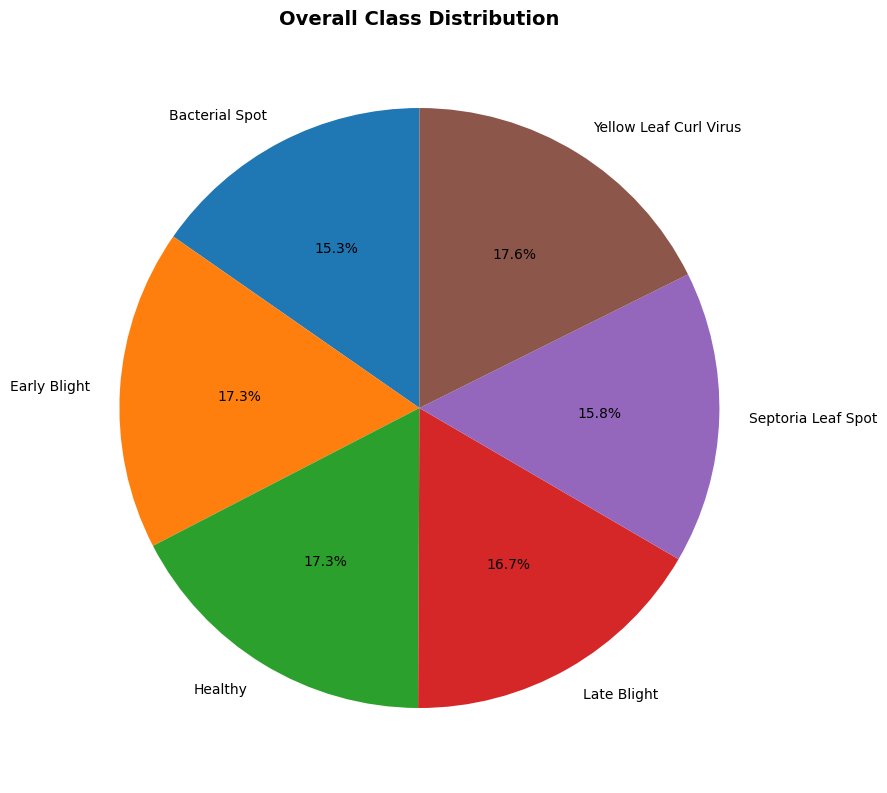

In [ ]:
#Visualize class distribution
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(14, 6))
x     = range(len(classes))
width = 0.25

ax.bar([i - width for i in x], df['Train'], width, label='Train', alpha=0.85)
ax.bar(x,                       df['Val'],   width, label='Val',   alpha=0.85)
ax.bar([i + width for i in x], df['Test'],  width, label='Test',  alpha=0.85)

ax.set_xlabel('Disease Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Image Distribution Across Classes', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(9, 9))
ax.pie(df['Total'], labels=df['Class'], autopct='%1.1f%%', startangle=90)
ax.set_title('Overall Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#Pool all images and apply stratified 80 / 10 / 10 split

from sklearn.model_selection import train_test_split

all_image_paths = []
all_labels      = []

print("Collecting all images from Train / Val / Test folders")
for class_name in classes:
    for split_dir in [train_path, val_path, test_path]:
        class_dir = os.path.join(split_dir, class_name)
        if not os.path.exists(class_dir):
            continue
        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
            if os.path.isfile(fpath):
                all_image_paths.append(fpath)
                all_labels.append(class_name)

print(f"Total images collected : {len(all_image_paths)}")
print(f"Total labels collected : {len(all_labels)}")

# 80 / 10 / 10 stratified split
train_images, temp_images, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42,
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42,
)

print(f"\nNew Split Distribution")
print(f"Training   : {len(train_images):5d}  ({len(train_images)/len(all_image_paths)*100:.1f}%)")
print(f"Validation : {len(val_images):5d}  ({len(val_images)/len(all_image_paths)*100:.1f}%)")
print(f"Test       : {len(test_images):5d}  ({len(test_images)/len(all_image_paths)*100:.1f}%)")
print(f"Total      : {len(train_images) + len(val_images) + len(test_images)}")

# Verify class distribution in new split
train_class_counts = pd.Series(train_labels).value_counts().sort_index()
val_class_counts   = pd.Series(val_labels).value_counts().sort_index()
test_class_counts  = pd.Series(test_labels).value_counts().sort_index()

split_df = pd.DataFrame({
    'Class': classes,
    'Train': [train_class_counts.get(c, 0) for c in classes],
    'Val':   [val_class_counts.get(c,   0) for c in classes],
    'Test':  [test_class_counts.get(c,  0) for c in classes],
})
split_df['Total'] = split_df['Train'] + split_df['Val'] + split_df['Test']

print("\nClass Distribution in New Split")
print(split_df.to_string(index=False))

Total images collected : 13887
Total labels collected : 13887

New Split Distribution
Training   : 11109  (80.0%)
Validation :  1389  (10.0%)
Test       :  1389  (10.0%)
Total      : 13887

Class Distribution in New Split
                 Class  Train  Val  Test  Total
        Bacterial Spot   1702  212   213   2127
          Early Blight   1920  240   240   2400
               Healthy   1925  241   241   2407
           Late Blight   1851  232   231   2314
    Septoria Leaf Spot   1750  219   219   2188
Yellow Leaf Curl Virus   1961  245   245   2451


In [ ]:
#Analyze image sizes and formats
import numpy as np
from PIL import Image

def get_image_info(image_paths, sample_size=200):

    widths, heights, formats = [], [], []
    sample = np.random.choice(image_paths, min(sample_size, len(image_paths)), replace=False)
    for path in sample:
        try:
            img = Image.open(path)
            widths.append(img.width)
            heights.append(img.height)
            formats.append(img.format)
        except Exception as e:
            print(f"  Error loading: {path} — {e}")
    return widths, heights, formats

print("Analyzing image properties from training set\n")
widths, heights, formats = get_image_info(train_images, sample_size=200)

print("Image Size Statistics")
print(f"Width  — Min: {min(widths)},  Max: {max(widths)},  Mean: {np.mean(widths):.1f}")
print(f"Height — Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.1f}")

print("\nImage Formats")
print(pd.Series(formats).value_counts().to_string())

unique_sizes = set(zip(widths, heights))
print(f"\nSize Uniformity")
print(f"Unique sizes found: {len(unique_sizes)}")
if len(unique_sizes) == 1:
    print(f"All images are the same size: {unique_sizes.pop()}")
else:
    print(" Images have varying sizes. Top 5:")
    top5 = pd.Series([f"{w}x{h}" for w, h in zip(widths, heights)]).value_counts().head(5)
    print(top5.to_string())


Analyzing image properties from training set

Image Size Statistics
Width  — Min: 256,  Max: 256,  Mean: 256.0
Height — Min: 256, Max: 256, Mean: 256.0

Image Formats
JPEG    200

Size Uniformity
Unique sizes found: 1
All images are the same size: (256, 256)


Displaying sample images from training set...



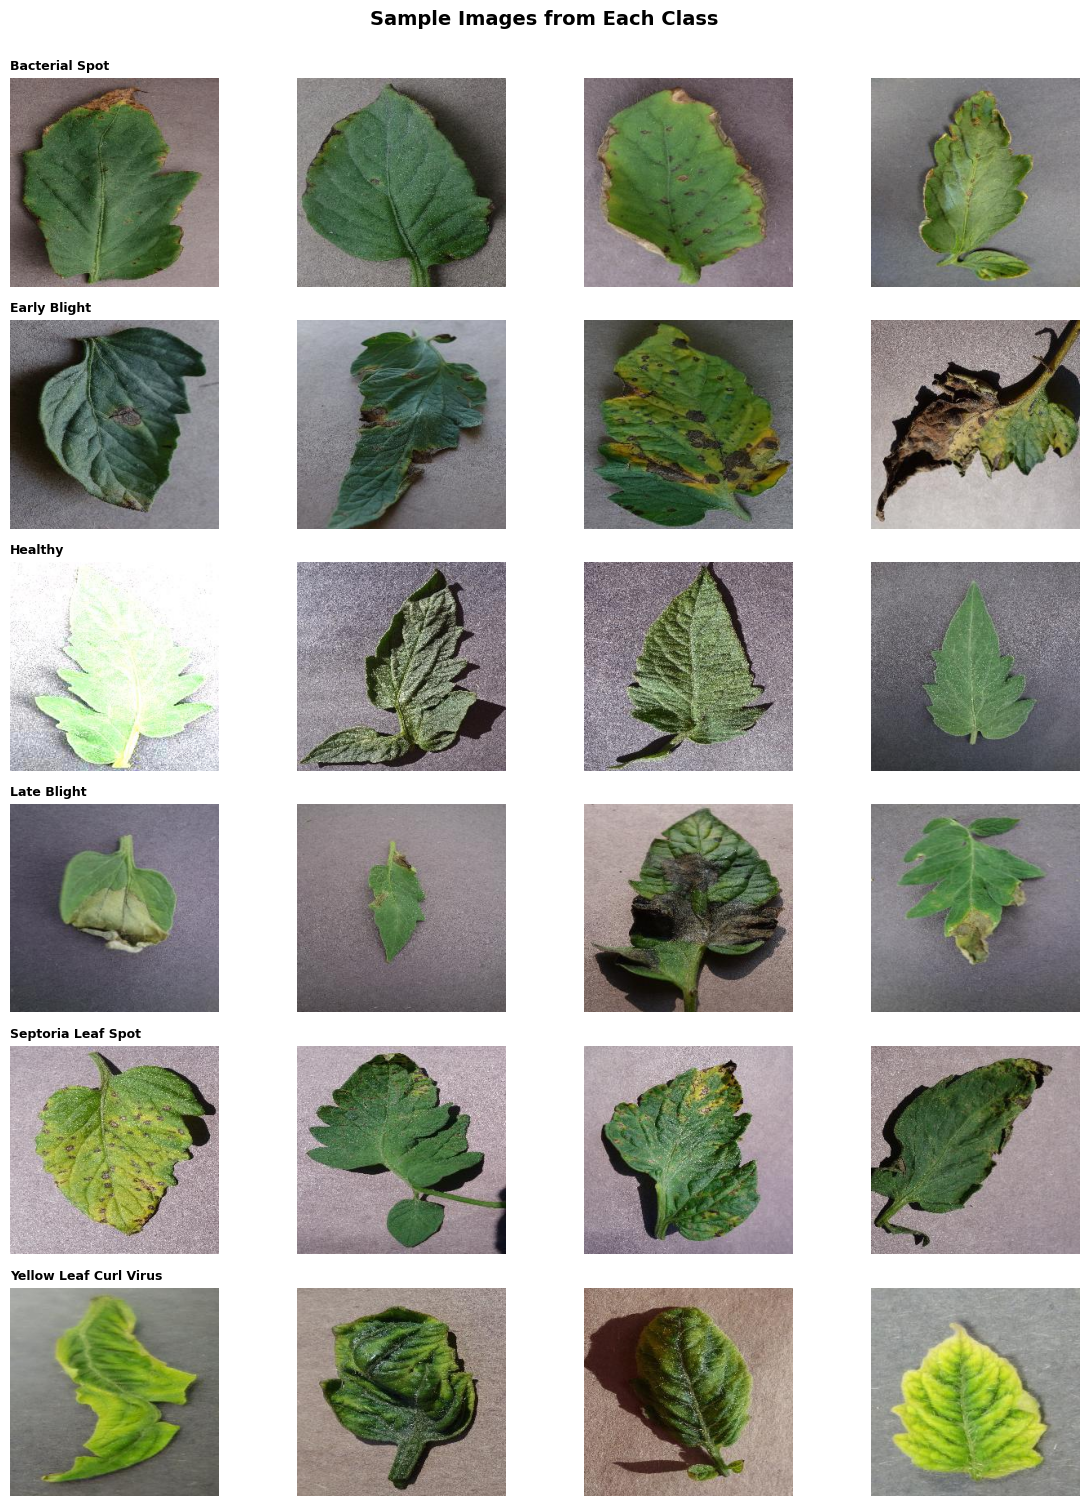

In [ ]:
# Display sample images per class
import random

def display_sample_images(image_paths, labels, classes, samples_per_class=4):

    fig, axes = plt.subplots(
        len(classes), samples_per_class,
        figsize=(samples_per_class * 3, len(classes) * 2.5)
    )

    for i, class_name in enumerate(classes):
        class_imgs = [p for p, l in zip(image_paths, labels) if l == class_name]
        samples    = random.sample(class_imgs, min(samples_per_class, len(class_imgs)))

        for j, img_path in enumerate(samples):
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.imshow(Image.open(img_path))
            ax.axis('off')
            if j == 0:
                ax.set_title(class_name, fontsize=9, fontweight='bold', loc='left')

    plt.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold', y=1.001)
    plt.tight_layout()
    plt.show()

print("Displaying sample images from training set...\n")
display_sample_images(train_images, train_labels, classes, samples_per_class=4)

In [ ]:
#PyTorch imports and device setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm

print("Environment Setup")
print(f"PyTorch Version     : {torch.__version__}")
print(f"Torchvision Version : {torchvision.__version__}")
print(f"CUDA Available      : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device          : {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs      : {torch.cuda.device_count()}")
else:
    print("Running on CPU")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("\nAll libraries imported successfully!")


Environment Setup
PyTorch Version     : 2.10.0+cu128
Torchvision Version : 0.25.0+cu128
CUDA Available      : True
GPU Device          : Tesla T4
Number of GPUs      : 1

Using device: cuda

All libraries imported successfully!


In [ ]:
# Custom Dataset class
class PlantDiseaseDataset(Dataset):


    def __init__(self, image_paths, labels, transform=None):
        self.image_paths  = image_paths
        self.labels       = labels
        self.transform    = transform

        self.class_names  = sorted(set(labels))
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}
        self.label_indices = [self.class_to_idx[lbl] for lbl in labels]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img   = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.label_indices[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


_tmp = PlantDiseaseDataset(train_images[:20], train_labels[:20])
print("Class → Index Mapping")
for name, idx in _tmp.class_to_idx.items():
    print(f"  {idx:2d}: {name}")
print(f"\n Dataset class ready. Total classes: {len(_tmp.class_names)}")


Class → Index Mapping
   0: Bacterial Spot
   1: Early Blight
   2: Healthy
   3: Late Blight
   4: Septoria Leaf Spot
   5: Yellow Leaf Curl Virus

 Dataset class ready. Total classes: 6


In [ ]:
# Define transforms
from PIL import ImageOps

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMAGE_SIZE    = 224


class AutoContrast:

    def __call__(self, img):
        return ImageOps.autocontrast(img)
    def __repr__(self):
        return "AutoContrast()"


# Training: augmentation + enhancement
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Enhancement
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.RandomAutocontrast(p=0.3),

    # Geometric augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),

    # Color augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),

    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),

    # Occlusion simulation
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1), ratio=(0.3, 3.3), value='random'),
])

# Validation / Test: deterministic, no augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    AutoContrast(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms Defined")
print("\nTraining (augmentation + enhancement):")
for t in train_transform.transforms:
    print(f"  {t}")

print("\nVal / Test (deterministic):")
for t in val_test_transform.transforms:
    print(f"  {t}")

print("\nTransforms ready!")

Transforms Defined

Training (augmentation + enhancement):
  Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  RandomAdjustSharpness(sharpness_factor=2,p=0.3)
  RandomAutocontrast(p=0.3)
  RandomHorizontalFlip(p=0.5)
  RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
  RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1))
  RandomPerspective(p=0.3)
  ColorJitter(brightness=(0.8, 1.2), contrast=(0.7, 1.3), saturation=(0.8, 1.2), hue=None)
  RandomGrayscale(p=0.1)
  ToTensor()
  Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  RandomErasing(p=0.3, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=random, inplace=False)

Val / Test (deterministic):
  Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  AutoContrast()
  ToTensor()
  Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

Transforms ready!


In [ ]:
#Create Datasets and DataLoaders
BATCH_SIZE = 32

train_dataset = PlantDiseaseDataset(train_images, train_labels, train_transform)
val_dataset   = PlantDiseaseDataset(val_images,   val_labels,   val_test_transform)
test_dataset  = PlantDiseaseDataset(test_images,  test_labels,  val_test_transform)

print("=== Dataset Sizes ===")
print(f"Training   : {len(train_dataset)}")
print(f"Validation : {len(val_dataset)}")
print(f"Test       : {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("\n=== DataLoader Configuration ===")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")

# Verify a batch loads correctly
images, labels_batch = next(iter(train_loader))
print(f"\n=== Batch Verification ===")
print(f"Image tensor shape : {images.shape}")   # [32, 3, 224, 224]
print(f"Labels shape       : {labels_batch.shape}")
print(f"Dtype              : {images.dtype}")
print(f"Value range        : [{images.min():.3f}, {images.max():.3f}]")

print("\nDatasets and DataLoaders ready!")


=== Dataset Sizes ===
Training   : 11109
Validation : 1389
Test       : 1389

=== DataLoader Configuration ===
Batch size         : 32
Training batches   : 348
Validation batches : 44
Test batches       : 44

=== Batch Verification ===
Image tensor shape : torch.Size([32, 3, 224, 224])
Labels shape       : torch.Size([32])
Dtype              : torch.float32
Value range        : [-4.050, 4.409]

Datasets and DataLoaders ready!


=== Training Augmentation ===


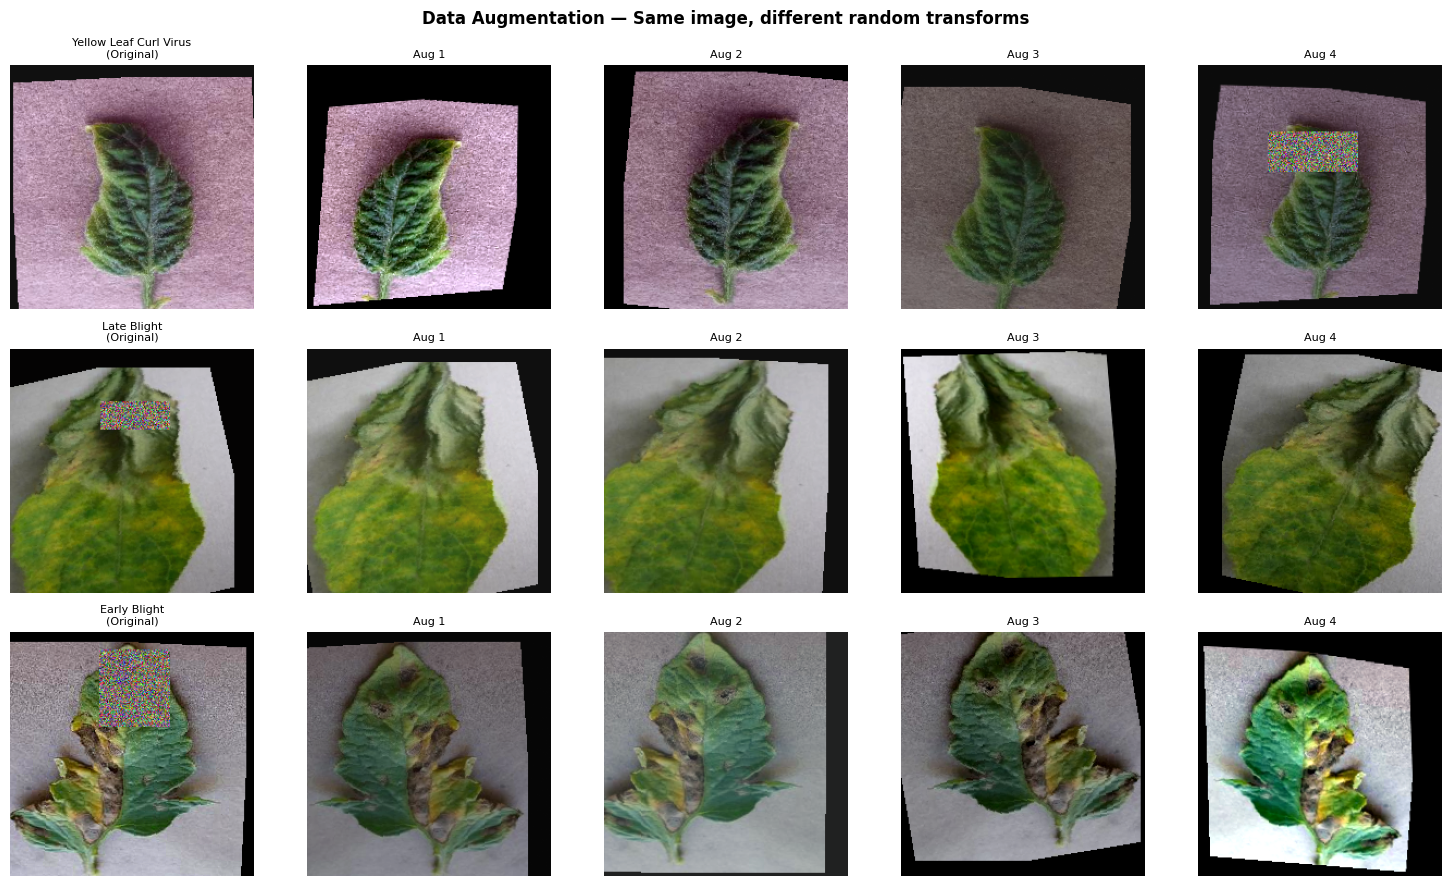


=== Validation Transform (should be identical every load) ===


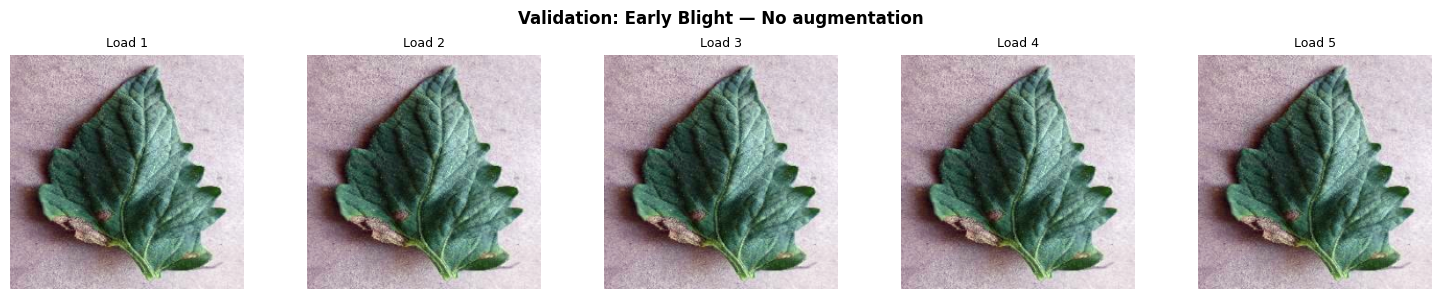


 Augmentation visualization complete!


In [ ]:
#Visualize data augmentation
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):

    t = tensor.clone()
    for c, m, s in zip(t, mean, std):
        c.mul_(s).add_(m)
    return torch.clamp(t, 0, 1)


def show_augmented_images(dataset, num_samples=3, augmentations_per_image=5):

    fig, axes = plt.subplots(
        num_samples, augmentations_per_image,
        figsize=(augmentations_per_image * 3, num_samples * 3)
    )
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    for row, idx in enumerate(indices):
        for col in range(augmentations_per_image):
            img_tensor, label = dataset[idx]
            img_display = denormalize(img_tensor).permute(1, 2, 0).numpy()

            ax = axes[row, col] if num_samples > 1 else axes[col]
            ax.imshow(img_display)
            ax.axis('off')
            if col == 0:
                ax.set_title(f"{dataset.class_names[label]}\n(Original)", fontsize=8)
            else:
                ax.set_title(f"Aug {col}", fontsize=8)

    plt.suptitle(
        'Data Augmentation — Same image, different random transforms',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

print("=== Training Augmentation ===")
show_augmented_images(train_dataset, num_samples=3, augmentations_per_image=5)

# Confirm val/test is deterministic (all 5 loads should look identical)
print("\n=== Validation Transform (should be identical every load) ===")
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
idx = np.random.randint(len(val_dataset))
for i in range(5):
    img_tensor, label = val_dataset[idx]
    img_display = denormalize(img_tensor).permute(1, 2, 0).numpy()
    axes[i].imshow(img_display)
    axes[i].axis('off')
    axes[i].set_title(f'Load {i+1}', fontsize=9)
plt.suptitle(
    f'Validation: {val_dataset.class_names[label]} — No augmentation',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()
print("\n Augmentation visualization complete!")

In [ ]:
#Check a random sample for corruption
import random

SAMPLE_RATE = 0.1  # check 10% of each split

def check_and_filter_sampled(image_paths, labels, split_name="", sample_rate=0.1):


    sample_size = max(50, int(len(image_paths) * sample_rate))
    sample_indices = random.sample(range(len(image_paths)), sample_size)

    print(f"\n{split_name} — checking {sample_size}/{len(image_paths)} images ({sample_rate*100:.0f}% sample)...")

    corrupted_in_sample = []
    for i in tqdm(sample_indices, desc=f"Sampling {split_name}"):
        try:
            with Image.open(image_paths[i]) as img:
                img.verify()
            with Image.open(image_paths[i]) as img:
                img.load()
                w, h = img.size
            if w < MIN_IMAGE_SIZE or h < MIN_IMAGE_SIZE:
                raise ValueError(f"Too small: {w}x{h}")
        except Exception as e:
            corrupted_in_sample.append((image_paths[i], str(e)))

    if len(corrupted_in_sample) == 0:
        print(f"  Sample clean — assuming full {split_name} set is OK. Skipping full check.")
        return image_paths, labels
    else:
        print(f"  Found {len(corrupted_in_sample)} issues in sample — running full check...")
        return check_and_filter(image_paths, labels, split_name)

MIN_IMAGE_SIZE = 50

train_images, train_labels = check_and_filter_sampled(train_images, train_labels, 'Train')
val_images,   val_labels   = check_and_filter_sampled(val_images,   val_labels,   'Val')
test_images,  test_labels  = check_and_filter_sampled(test_images,  test_labels,  'Test')

print("\n Corruption check complete!")

# Rebuild datasets and loaders
train_dataset = PlantDiseaseDataset(train_images, train_labels, train_transform)
val_dataset   = PlantDiseaseDataset(val_images,   val_labels,   val_test_transform)
test_dataset  = PlantDiseaseDataset(test_images,  test_labels,  val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


Train — checking 1110/11109 images (10% sample)...


Sampling Train: 100%|██████████| 1110/1110 [04:54<00:00,  3.76it/s]


  Sample clean — assuming full Train set is OK. Skipping full check.

Val — checking 138/1389 images (10% sample)...


Sampling Val: 100%|██████████| 138/138 [00:34<00:00,  4.04it/s]


  Sample clean — assuming full Val set is OK. Skipping full check.

Test — checking 138/1389 images (10% sample)...


Sampling Test: 100%|██████████| 138/138 [00:35<00:00,  3.85it/s]

  Sample clean — assuming full Test set is OK. Skipping full check.

 Corruption check complete!


In [ ]:
#Class distribution and class weights
from collections import Counter

train_label_counts = Counter(train_labels)

print("=== Class Distribution in Training Set ===")
for class_name in classes:
    count = train_label_counts[class_name]
    pct   = count / len(train_labels) * 100
    print(f"  {class_name:35s}: {count:5d}  ({pct:5.2f}%)")

# Inverse-frequency class weights
total_samples = len(train_labels)
num_classes   = len(classes)
class_weights = {
    c: total_samples / (num_classes * train_label_counts[c])
    for c in classes
}

print("\n=== Class Weights (for loss function) ===")
for class_name in classes:
    print(f"  {class_name:35s}: {class_weights[class_name]:.4f}")

# Tensor for PyTorch loss function
weight_list          = [class_weights[c] for c in sorted(classes)]
class_weights_tensor = torch.FloatTensor(weight_list).to(device)

print(f"\nClass weights tensor:\n  {class_weights_tensor}")

# Balance analysis
max_w    = max(weight_list)
min_w    = min(weight_list)
variance = max_w / min_w

print(f"\n=== Balance Analysis ===")
print(f"Weight variance ratio: {variance:.2f}")
if variance < 1.2:
    print("Dataset is well-balanced.")
else:
    print(f"Imbalance detected (ratio {variance:.2f}). Class weights will help training.")



=== Class Distribution in Training Set ===
  Bacterial Spot                     :  1702  (15.32%)
  Early Blight                       :  1920  (17.28%)
  Healthy                            :  1925  (17.33%)
  Late Blight                        :  1851  (16.66%)
  Septoria Leaf Spot                 :  1750  (15.75%)
  Yellow Leaf Curl Virus             :  1961  (17.65%)

=== Class Weights (for loss function) ===
  Bacterial Spot                     : 1.0878
  Early Blight                       : 0.9643
  Healthy                            : 0.9618
  Late Blight                        : 1.0003
  Septoria Leaf Spot                 : 1.0580
  Yellow Leaf Curl Virus             : 0.9442

Class weights tensor:
  tensor([1.0878, 0.9643, 0.9618, 1.0003, 1.0580, 0.9442], device='cuda:0')

=== Balance Analysis ===
Weight variance ratio: 1.15
Dataset is well-balanced.


=== Image Quality Check (sample of 200 training images) ===



Analyzing: 100%|██████████| 200/200 [00:46<00:00,  4.33it/s]


=== Quality Statistics ===
Blur Score  — Mean: 4319.69,  Std: 4891.29
Brightness  — Mean: 115.53,  Std: 26.08
Contrast    — Mean: 39.72,  Std: 12.60

=== Quality Issues Found ===
Blurry        :   8  (4.0%)
Too dark      :   3  (1.5%)
Too bright    :   5  (2.5%)
Low contrast  :  54  (27.0%)

=== Overall Quality ===
MODERATE — 35.0% issues. Filtering recommended.


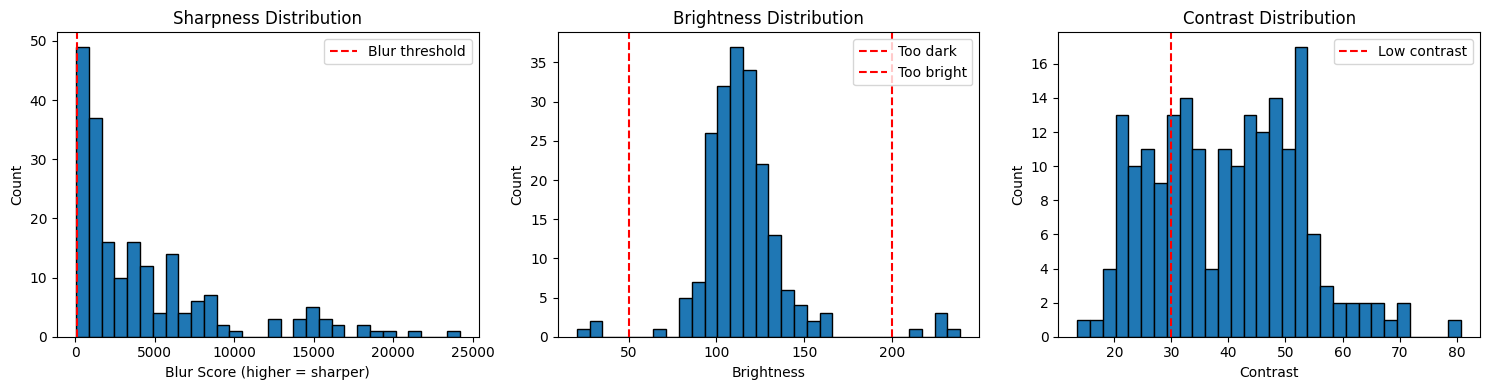

In [ ]:
# Image quality check (blur, brightness, contrast)
import cv2

def check_image_quality(img_path):

    try:
        img_array = np.array(Image.open(img_path))
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY) if img_array.ndim == 3 else img_array
        return {
            'path':           img_path,
            'blur_score':     cv2.Laplacian(gray, cv2.CV_64F).var(),
            'brightness':     float(np.mean(gray)),
            'contrast':       float(np.std(gray)),
            'is_blurry':      cv2.Laplacian(gray, cv2.CV_64F).var() < 100,
            'is_dark':        np.mean(gray) < 50,
            'is_bright':      np.mean(gray) > 200,
            'is_low_contrast':np.std(gray) < 30,
        }
    except Exception:
        return None

print("=== Image Quality Check (sample of 200 training images) ===\n")
sample_size    = min(200, len(train_images))
sample_indices = np.random.choice(len(train_images), sample_size, replace=False)
sample_paths   = [train_images[i] for i in sample_indices]

quality_results = [r for r in
                   (check_image_quality(p) for p in tqdm(sample_paths, desc="Analyzing"))
                   if r is not None]

blur_scores       = [r['blur_score']  for r in quality_results]
brightness_scores = [r['brightness']  for r in quality_results]
contrast_scores   = [r['contrast']    for r in quality_results]

blurry_images      = [r for r in quality_results if r['is_blurry']]
dark_images        = [r for r in quality_results if r['is_dark']]
bright_images      = [r for r in quality_results if r['is_bright']]
low_contrast_imgs  = [r for r in quality_results if r['is_low_contrast']]

print("=== Quality Statistics ===")
print(f"Blur Score  — Mean: {np.mean(blur_scores):.2f},  Std: {np.std(blur_scores):.2f}")
print(f"Brightness  — Mean: {np.mean(brightness_scores):.2f},  Std: {np.std(brightness_scores):.2f}")
print(f"Contrast    — Mean: {np.mean(contrast_scores):.2f},  Std: {np.std(contrast_scores):.2f}")

print("\n=== Quality Issues Found ===")
n = len(quality_results)
print(f"Blurry        : {len(blurry_images):3d}  ({len(blurry_images)/n*100:.1f}%)")
print(f"Too dark      : {len(dark_images):3d}  ({len(dark_images)/n*100:.1f}%)")
print(f"Too bright    : {len(bright_images):3d}  ({len(bright_images)/n*100:.1f}%)")
print(f"Low contrast  : {len(low_contrast_imgs):3d}  ({len(low_contrast_imgs)/n*100:.1f}%)")

total_issues = len(blurry_images) + len(dark_images) + len(bright_images) + len(low_contrast_imgs)
issue_rate   = total_issues / n * 100

print(f"\n=== Overall Quality ===")
if issue_rate < 5:
    print(f"EXCELLENT — only {issue_rate:.1f}% of images have issues. No filtering needed.")
elif issue_rate < 15:
    print(f"GOOD — {issue_rate:.1f}% minor issues. Optional filtering.")
else:
    print(f"MODERATE — {issue_rate:.1f}% issues. Filtering recommended.")

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(blur_scores, bins=30, edgecolor='black')
axes[0].axvline(100, color='r', linestyle='--', label='Blur threshold')
axes[0].set_xlabel('Blur Score (higher = sharper)')
axes[0].set_ylabel('Count')
axes[0].set_title('Sharpness Distribution')
axes[0].legend()

axes[1].hist(brightness_scores, bins=30, edgecolor='black')
axes[1].axvline(50,  color='r', linestyle='--', label='Too dark')
axes[1].axvline(200, color='r', linestyle='--', label='Too bright')
axes[1].set_xlabel('Brightness')
axes[1].set_ylabel('Count')
axes[1].set_title('Brightness Distribution')
axes[1].legend()

axes[2].hist(contrast_scores, bins=30, edgecolor='black')
axes[2].axvline(30, color='r', linestyle='--', label='Low contrast')
axes[2].set_xlabel('Contrast')
axes[2].set_ylabel('Count')
axes[2].set_title('Contrast Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()


In [ ]:
from torchvision.utils import save_image

processed_base = '/content/drive/MyDrive/ML Project Dataset /Plant Village/Tomato/processed'
AUG_COPIES = 10

def save_processed_split_augmented(loader, dataset, split_name, aug_copies=1):
    save_dir = os.path.join(processed_base, split_name)
    os.makedirs(save_dir, exist_ok=True)

    print(f"\nSaving {split_name}...")

    for epoch in range(aug_copies if split_name == 'train' else 1):
        for images, labels in tqdm(loader, desc=f"{split_name} copy {epoch+1}/{aug_copies}"):
            for i in range(len(images)):
                class_name = dataset.class_names[labels[i].item()]
                class_dir  = os.path.join(save_dir, class_name)
                os.makedirs(class_dir, exist_ok=True)

                fname_base = os.path.splitext(os.path.basename(dataset.image_paths[i]))[0]
                fname = f"{fname_base}_aug{epoch}.png" if split_name == 'train' else f"{fname_base}.png"
                save_image(images[i], os.path.join(class_dir, fname))

    print(f" {split_name} saved to {save_dir}")

save_processed_split_augmented(train_loader, train_dataset, 'train', aug_copies=AUG_COPIES)
save_processed_split_augmented(val_loader,   val_dataset,   'val')
save_processed_split_augmented(test_loader,  test_dataset,  'test')


Saving train...


train copy 10/10: 100%|██████████| 348/348 [05:30<00:00,  1.05it/s]


 train saved to /content/drive/MyDrive/ML Project Dataset /Plant Village/Tomato/processed/train

Saving val...


val copy 1/1: 100%|██████████| 44/44 [02:56<00:00,  4.02s/it]


 val saved to /content/drive/MyDrive/ML Project Dataset /Plant Village/Tomato/processed/val

Saving test...


test copy 1/1: 100%|██████████| 44/44 [02:56<00:00,  4.01s/it]

 test saved to /content/drive/MyDrive/ML Project Dataset /Plant Village/Tomato/processed/test
